In [ ]:
! pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 57.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

In [10]:
! wget -r -N -c -np https://physionet.org/files/qtdb/1.0.0/

--2026-07-22 11:49:41--  https://physionet.org/files/qtdb/1.0.0/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/qtdb/1.0.0/index.html’

physionet.org/files     [     <=>            ] 125.67K  5.10KB/s    in 25s     

Last-modified header missing -- time-stamps turned off.
2026-07-22 11:50:11 (5.10 KB/s) - ‘physionet.org/files/qtdb/1.0.0/index.html’ saved [128682]

Loading robots.txt; please ignore errors.
--2026-07-22 11:50:11--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-07-22 11:50:12--  https://physionet.org/files/qtdb/1.0.0/doc/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecifie

In [5]:
# ==========================================
# Google Drive Save Paths
# ==========================================

MODEL_SAVE_PATH = "best_ml2_model.pth"
NORMALIZATION_SAVE_PATH = "best_ml2_normalization.npz"

In [6]:
# manually enter the data directory path based on which service you're using(CUDA, Colab, Mac)
DATA_DIR = input("Enter the data directory path (e.g., /content/physionet.org/files/qtdb/1.0.0/): ")

In [13]:
DATA_DIR = "physionet.org/files/qtdb/1.0.0/"

RECORD = "sel100"

record_path = f"{DATA_DIR}/{RECORD}"

print("Record Path :")

print(record_path)

Record Path :
physionet.org/files/qtdb/1.0.0//sel100


In [14]:
files = sorted(os.listdir(DATA_DIR))


records = sorted(list(set(f.split(".")[0] for f in files if f.endswith(".dat"))))


print("Total Records :", len(records))

print()

print("First 20 Records :")

print()

print(records[:20])

Total Records : 105

First 20 Records :

['sel100', 'sel102', 'sel103', 'sel104', 'sel114', 'sel116', 'sel117', 'sel123', 'sel14046', 'sel14157', 'sel14172', 'sel15814', 'sel16265', 'sel16272', 'sel16273', 'sel16420', 'sel16483', 'sel16539', 'sel16773', 'sel16786']


In [15]:
record = wfdb.rdrecord(record_path)

print("Sampling Frequency :", record.fs)

print()

print("Signal Names :")

print(record.sig_name)

print()

print("Signal Shape :")

print(record.p_signal.shape)

Sampling Frequency : 250

Signal Names :
['MLII', 'V5']

Signal Shape :
(225000, 2)


In [16]:
ecg = record.p_signal[:, 0]

print("Lead Used :")

print(record.sig_name[0])

print()

print("ECG Shape :")

print(ecg.shape)

print()

print("First 10 Samples :")

print(ecg[:10])

Lead Used :
MLII

ECG Shape :
(225000,)

First 10 Samples :
[4.725 4.735 4.725 4.715 4.72  4.705 4.7   4.69  4.71  4.71 ]


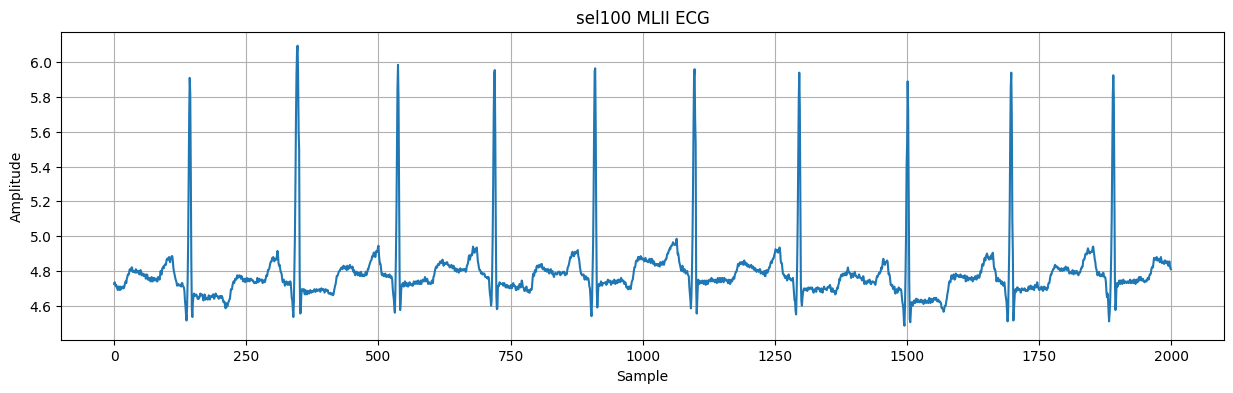

In [17]:
plt.figure(figsize=(15, 4))

plt.plot(ecg[:2000])

plt.title(f"{RECORD} MLII ECG")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

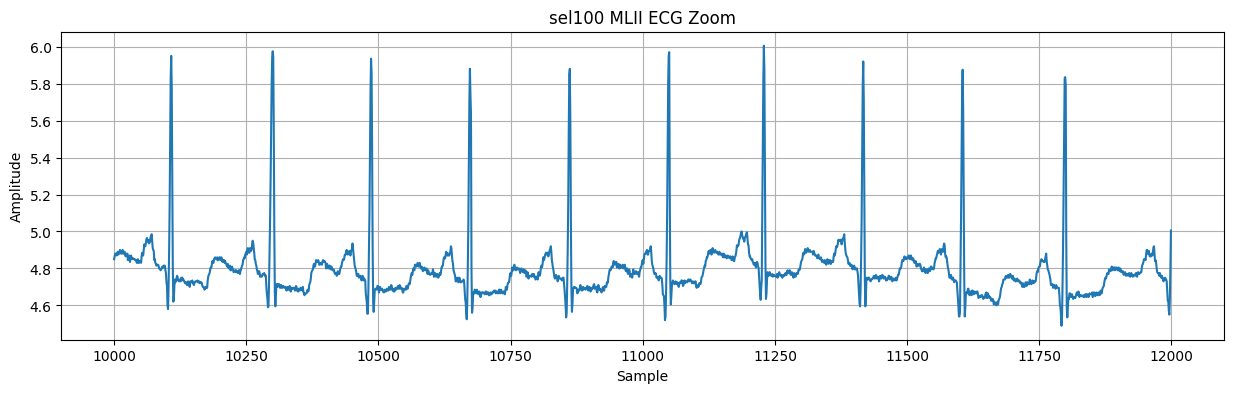

In [18]:
start = 10000

end = 12000


plt.figure(figsize=(15, 4))

plt.plot(np.arange(start, end), ecg[start:end])

plt.title(f"{RECORD} MLII ECG Zoom")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [19]:
print("Minimum :", np.min(ecg))
print("Maximum :", np.max(ecg))
print("Mean :", np.mean(ecg))
print("Std :", np.std(ecg))

Minimum : 4.44
Maximum : 6.53
Mean : 4.8187722444444425
Std : 0.19179856115398844


In [20]:
pu0 = wfdb.rdann(record_path, "pu0")

print("Number of Annotations :", len(pu0.sample))

print()

print("Unique Symbols :")

print(sorted(set(pu0.symbol)))

Number of Annotations : 11011

Unique Symbols :
['(', ')', 'N', 'p', 't']


In [21]:
for i in range(30):
    print(i, pu0.sample[i], pu0.symbol[i])

0 83 (
1 104 p
2 116 )
3 130 (
4 142 N
5 152 )
6 201 (
7 210 t
8 235 t
9 245 )
10 285 (
11 305 p
12 318 )
13 332 (
14 346 N
15 356 )
16 412 (
17 438 t
18 456 )
19 477 (
20 495 p
21 506 )
22 524 (
23 536 N
24 546 )
25 588 (
26 596 t
27 618 t
28 647 )
29 664 (


In [22]:
labels = np.zeros(len(ecg), dtype=np.int32)

start_idx = None
wave_type = None

for sample, symbol in zip(pu0.sample, pu0.symbol):
    # Wave Starts
    if symbol == "(":
        start_idx = sample

    # P Wave
    elif symbol == "p":
        wave_type = 1

    # QRS Complex
    elif symbol == "N":
        wave_type = 2

    # T Wave
    elif symbol == "t":
        wave_type = 3

    # Wave Ends
    elif symbol == ")":
        if start_idx is not None and wave_type is not None:
            labels[start_idx : sample + 1] = wave_type
            start_idx = None
            wave_type = None

print("ECG Shape :", ecg.shape)

print("Labels Shape :", labels.shape)

print()

print("Unique Labels :")

print(np.unique(labels))

ECG Shape : (225000,)
Labels Shape : (225000,)

Unique Labels :
[0 1 2 3]


In [23]:
def generate_labels(ecg, pu0):

    labels = np.zeros(len(ecg), dtype=np.int32)

    start_idx = None

    wave_type = None

    for sample, symbol in zip(pu0.sample, pu0.symbol):
        # Wave Start

        if symbol == "(":
            start_idx = sample

        # P Wave

        elif symbol == "p":
            wave_type = 1

        # QRS

        elif symbol == "N":
            wave_type = 2

        # T Wave

        elif symbol == "t":
            wave_type = 3

        # Wave End

        elif symbol == ")":
            if start_idx is not None and wave_type is not None:
                labels[start_idx : sample + 1] = wave_type

                start_idx = None

                wave_type = None

    return labels

In [24]:
labels_test = generate_labels(ecg, pu0)


print("Labels Shape :")

print(labels_test.shape)

print()


print("Unique Labels :")

print(np.unique(labels_test))


print()

print("Label Counts :")

print(np.bincount(labels_test))

Labels Shape :
(225000,)

Unique Labels :
[0 1 2 3]

Label Counts :
[99454 33982 24111 67453]


In [25]:
print(np.bincount(labels))

[99454 33982 24111 67453]


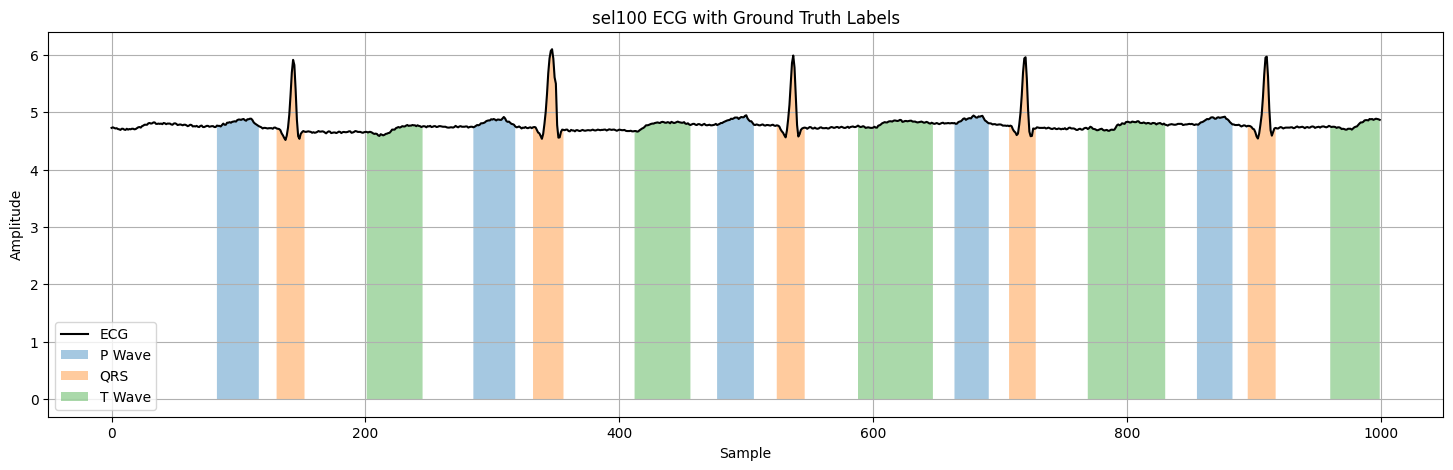

In [26]:
start = 0
end = 1000

plt.figure(figsize=(18, 5))

# ECG

plt.plot(
    np.arange(start, end), ecg[start:end], color="black", linewidth=1.5, label="ECG"
)


# P Wave

mask = labels[start:end] == 1

plt.fill_between(
    np.arange(start, end), ecg[start:end], where=mask, alpha=0.4, label="P Wave"
)


# QRS

mask = labels[start:end] == 2

plt.fill_between(
    np.arange(start, end), ecg[start:end], where=mask, alpha=0.4, label="QRS"
)


# T Wave

mask = labels[start:end] == 3

plt.fill_between(
    np.arange(start, end), ecg[start:end], where=mask, alpha=0.4, label="T Wave"
)


plt.title(f"{RECORD} ECG with Ground Truth Labels")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.legend()

plt.show()

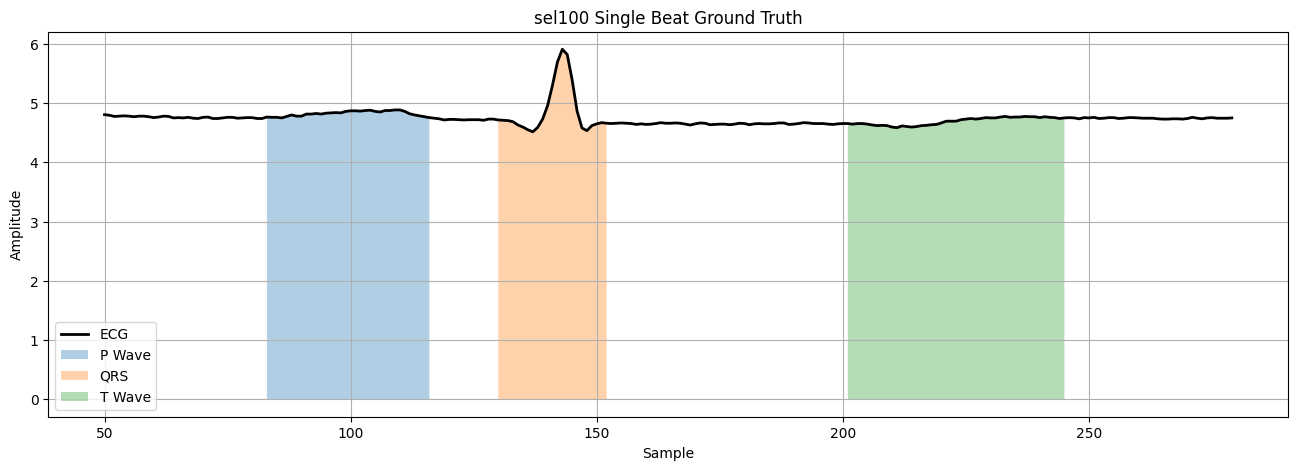

In [27]:
start = 50

end = 280


x = np.arange(start, end)


plt.figure(figsize=(16, 5))


# ECG

plt.plot(x, ecg[start:end], linewidth=2, color="black", label="ECG")


# P Wave

mask = labels[start:end] == 1

plt.fill_between(x, ecg[start:end], where=mask, alpha=0.35, label="P Wave")


# QRS

mask = labels[start:end] == 2

plt.fill_between(x, ecg[start:end], where=mask, alpha=0.35, label="QRS")


# T Wave

mask = labels[start:end] == 3

plt.fill_between(x, ecg[start:end], where=mask, alpha=0.35, label="T Wave")


plt.title(f"{RECORD} Single Beat Ground Truth")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.legend()

plt.show()

In [28]:
def create_windows(signal, labels, window_size=512, stride=256):

    X = []

    Y = []

    for start in range(0, len(signal) - window_size + 1, stride):
        end = start + window_size

        X.append(signal[start:end])

        Y.append(labels[start:end])

    X = np.array(X)

    Y = np.array(Y)

    return X, Y

In [29]:
X, Y = create_windows(ecg, labels, window_size=512, stride=256)


print("ECG Window Shape :")

print(X.shape)

print()


print("Label Window Shape :")

print(Y.shape)

ECG Window Shape :
(877, 512)

Label Window Shape :
(877, 512)


In [30]:
X_total = []

Y_total = []

record_ids = []


for RECORD in records:
    print(f"Processing: {RECORD}")

    record_path = f"{DATA_DIR}/{RECORD}"

    try:
        # Load ECG
        record = wfdb.rdrecord(record_path)
        ecg = record.p_signal[:, 0]

        # Load annotations
        pu0 = wfdb.rdann(record_path, "pu0")

        # Generate labels
        labels = generate_labels(ecg, pu0)

        # Create windows
        X, Y = create_windows(ecg, labels, window_size=512, stride=256)

        # Store windows
        X_total.append(X)
        Y_total.append(Y)

        # Store record name for every window
        record_ids.extend([RECORD] * len(X))

    except Exception as e:
        print(f"Skipped {RECORD}")

        print(e)

print("\nDataset Creation Complete!")

Processing: sel100
Processing: sel102
Processing: sel103
Processing: sel104
Processing: sel114
Processing: sel116
Processing: sel117
Processing: sel123
Processing: sel14046
Processing: sel14157
Processing: sel14172
Processing: sel15814
Processing: sel16265
Processing: sel16272
Processing: sel16273
Processing: sel16420
Processing: sel16483
Processing: sel16539
Processing: sel16773
Processing: sel16786
Processing: sel16795
Processing: sel17152
Processing: sel17453
Processing: sel213
Processing: sel221
Processing: sel223
Processing: sel230
Processing: sel231
Processing: sel232
Processing: sel233
Processing: sel30
Processing: sel301
Processing: sel302
Processing: sel306
Processing: sel307
Processing: sel308
Processing: sel31
Processing: sel310
Processing: sel32
Processing: sel33
Processing: sel34
Processing: sel35
Processing: sel36
Processing: sel37
Processing: sel38
Processing: sel39
Processing: sel40
Processing: sel41
Processing: sel42
Processing: sel43
Processing: sel44
Processing: sel4

In [31]:
X_total = np.concatenate(X_total, axis=0)

Y_total = np.concatenate(Y_total, axis=0)

record_ids = np.array(record_ids)


print("X_total Shape :", X_total.shape)

print("Y_total Shape :", Y_total.shape)

print("Record IDs Shape :", record_ids.shape)

print()

print("Unique Labels :")

print(np.unique(Y_total))

print()

print("Total Records Represented :")

print(len(np.unique(record_ids)))

X_total Shape : (92085, 512)
Y_total Shape : (92085, 512)
Record IDs Shape : (92085,)

Unique Labels :
[0 1 2 3]

Total Records Represented :
105


In [32]:
print("First 10 Record IDs:\n")

print(record_ids[:10])

print()

print("Last 10 Record IDs:\n")

print(record_ids[-10:])

print()

print("Unique Records:")

print(len(np.unique(record_ids)))

First 10 Record IDs:

['sel100' 'sel100' 'sel100' 'sel100' 'sel100' 'sel100' 'sel100' 'sel100'
 'sel100' 'sel100']

Last 10 Record IDs:

['sele0704' 'sele0704' 'sele0704' 'sele0704' 'sele0704' 'sele0704'
 'sele0704' 'sele0704' 'sele0704' 'sele0704']

Unique Records:
105


In [33]:
print("First 10 Record IDs")

First 10 Record IDs


In [34]:
from sklearn.model_selection import train_test_split

# Get all unique record names
unique_records = np.unique(record_ids)

# Split records (80% train, 20% validation)
train_records, val_records = train_test_split(
    unique_records, test_size=0.20, random_state=42, shuffle=True
)

print("Training Records :", len(train_records))
print("Validation Records :", len(val_records))

print("\nFirst 10 Training Records:")
print(train_records[:10])

print("\nFirst 10 Validation Records:")
print(val_records[:10])

Training Records : 84
Validation Records : 21

First 10 Training Records:
['sel49' 'sel17453' 'sele0111' 'sel38' 'sele0104' 'sel16420' 'sel36'
 'sel34' 'sel14157' 'sele0133']

First 10 Validation Records:
['sel30' 'sel847' 'sel840' 'sel47' 'sel39' 'sele0406' 'sele0704' 'sel41'
 'sel14172' 'sel100']


In [35]:
# Create boolean masks

train_mask = np.isin(record_ids, train_records)

val_mask = np.isin(record_ids, val_records)

print("Training Windows :", np.sum(train_mask))
print("Validation Windows :", np.sum(val_mask))

print()

print("Total Windows :", len(record_ids))
print("Mask Check :", np.sum(train_mask) + np.sum(val_mask))

Training Windows : 73668
Validation Windows : 18417

Total Windows : 92085
Mask Check : 92085


In [36]:
# Create train dataset

X_train = X_total[train_mask]
Y_train = Y_total[train_mask]

# Create validation dataset

X_val = X_total[val_mask]
Y_val = Y_total[val_mask]

print("X_train Shape :", X_train.shape)
print("Y_train Shape :", Y_train.shape)

print()

print("X_val Shape :", X_val.shape)
print("Y_val Shape :", Y_val.shape)

X_train Shape : (73668, 512)
Y_train Shape : (73668, 512)

X_val Shape : (18417, 512)
Y_val Shape : (18417, 512)


In [37]:
# ==========================================
# Compute Normalization Statistics
# (Training Set Only)
# ==========================================

train_mean = np.mean(X_train)

train_std = np.std(X_train)

np.savez(NORMALIZATION_SAVE_PATH, train_mean=train_mean, train_std=train_std)
print("Saved training scale :", NORMALIZATION_SAVE_PATH)

print("Training Mean :", train_mean)

print("Training Std  :", train_std)

Saved training scale : best_ml2_normalization.npz
Training Mean : -0.023794946955853293
Training Std  : 2.9930434224033347


In [38]:
# ==========================================
# Normalize ECG
# ==========================================

X_train = (X_train - train_mean) / train_std

X_val = (X_val - train_mean) / train_std

print("Normalization Complete!")

Normalization Complete!


In [39]:
print("Training Mean After Normalization :", np.mean(X_train))

print("Training Std After Normalization :", np.std(X_train))

print()

print("Validation Mean :", np.mean(X_val))


print("Validation Std :", np.std(X_val))

Training Mean After Normalization : 4.1914430635927203e-16
Training Std After Normalization : 0.9999999999999996

Validation Mean : -0.014163711423158004
Validation Std : 0.715813884913146


In [40]:
import torch

# ==========================================
# Convert NumPy arrays to PyTorch tensors
# ==========================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)

print("Conversion Complete!\n")

print("X_train_tensor :", X_train_tensor.shape, X_train_tensor.dtype)
print("Y_train_tensor :", Y_train_tensor.shape, Y_train_tensor.dtype)

print()

print("X_val_tensor   :", X_val_tensor.shape, X_val_tensor.dtype)
print("Y_val_tensor   :", Y_val_tensor.shape, Y_val_tensor.dtype)

Conversion Complete!

X_train_tensor : torch.Size([73668, 512]) torch.float32
Y_train_tensor : torch.Size([73668, 512]) torch.int64

X_val_tensor   : torch.Size([18417, 512]) torch.float32
Y_val_tensor   : torch.Size([18417, 512]) torch.int64


In [51]:
# ==========================================
# Add Channel Dimension for CNN
# ==========================================

X_train_tensor = X_train_tensor.unsqueeze(1)

X_val_tensor = X_val_tensor.unsqueeze(1)

print("Channel Dimension Added!\n")

print("X_train_tensor :", X_train_tensor.shape)

print("X_val_tensor   :", X_val_tensor.shape)

print()

print("Y_train_tensor :", Y_train_tensor.shape)

print("Y_val_tensor   :", Y_val_tensor.shape)

Channel Dimension Added!

X_train_tensor : torch.Size([73668, 1, 1, 512])
X_val_tensor   : torch.Size([18417, 1, 1, 512])

Y_train_tensor : torch.Size([73668, 512])
Y_val_tensor   : torch.Size([18417, 512])


In [52]:
from torch.utils.data import TensorDataset

# ==========================================
# Create Tensor Datasets
# ==========================================

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

print("Datasets Created Successfully!\n")

print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

Datasets Created Successfully!

Training Samples : 73668
Validation Samples : 18417


In [53]:
sample_ecg, sample_label = train_dataset[0]

print("ECG Shape :", sample_ecg.shape)

print("Label Shape :", sample_label.shape)

print()

print("Unique Labels in this sample:")

print(torch.unique(sample_label))

ECG Shape : torch.Size([1, 1, 512])
Label Shape : torch.Size([512])

Unique Labels in this sample:
tensor([0, 1, 2, 3])


In [54]:
from torch.utils.data import DataLoader

# ==========================================
# Create DataLoaders
# ==========================================

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders Created Successfully!\n")

print("Training Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))

DataLoaders Created Successfully!

Training Batches : 1152
Validation Batches : 288


In [55]:
# ==========================================
# Inspect One Batch
# ==========================================

batch_ecg, batch_labels = next(iter(train_loader))

print("ECG Batch Shape :", batch_ecg.shape)

print("Label Batch Shape :", batch_labels.shape)

print()

print("ECG Data Type :", batch_ecg.dtype)

print("Label Data Type :", batch_labels.dtype)

print()

print("Unique Labels in Batch:")

print(torch.unique(batch_labels))

ECG Batch Shape : torch.Size([64, 1, 1, 512])
Label Batch Shape : torch.Size([64, 512])

ECG Data Type : torch.float32
Label Data Type : torch.int64

Unique Labels in Batch:
tensor([0, 1, 2, 3])


In [56]:
print(" STARTING CNN ARCHITECHTURE")

 STARTING CNN ARCHITECHTURE


In [57]:
import torch.nn as nn

# ==========================================
# CNN Feature Extractor
# ==========================================


class CNNFeatureExtractor(nn.Module):
    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(
            # -------------------------
            # Block 1
            # -------------------------
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            # -------------------------
            # Block 2
            # -------------------------
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

    def forward(self, x):

        return self.features(x)

In [58]:
# ==========================================
# Test CNN Feature Extractor
# ==========================================

cnn = CNNFeatureExtractor()

batch_ecg, batch_labels = next(iter(train_loader))

features = cnn(batch_ecg)

print("Input Shape  :", batch_ecg.shape)

print("Feature Shape :", features.shape)

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [64, 1, 1, 512]

In [48]:
# ==========================================
# Prepare CNN Features for BiLSTM
# ==========================================

batch_ecg, batch_labels = next(iter(train_loader))

features = cnn(batch_ecg)

print("Before Permute :", features.shape)

features = features.permute(0, 2, 1)

print("After Permute  :", features.shape)

Before Permute : torch.Size([64, 64, 512])
After Permute  : torch.Size([64, 512, 64])


In [59]:
# ==========================================
# BiLSTM Block
# ==========================================


class BiLSTMBlock(nn.Module):
    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        return output

In [60]:
# ==========================================
# Test BiLSTM
# ==========================================

bilstm = BiLSTMBlock()

output = bilstm(features)

print("Input to BiLSTM :", features.shape)

print("Output Shape    :", output.shape)

NameError: name 'features' is not defined

In [61]:
# ==========================================
# Complete ML2 Baseline Model
# ==========================================


class ML2Model(nn.Module):
    def __init__(self):

        super().__init__()

        # CNN
        self.cnn = CNNFeatureExtractor()

        # BiLSTM
        self.bilstm = BiLSTMBlock()

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Classifier
        self.classifier = nn.Linear(256, 4)

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # (Batch, Channels, Length)
        # ->
        # (Batch, Length, Channels)

        x = x.permute(0, 2, 1)

        # BiLSTM

        x = self.bilstm(x)

        # Dropout

        x = self.dropout(x)

        # Classifier

        x = self.classifier(x)

        return x

In [62]:
# ==========================================
# Test Complete ML2 Model
# ==========================================

model = ML2Model()

batch_ecg, batch_labels = next(iter(train_loader))

predictions = model(batch_ecg)

print("Input Shape :")

print(batch_ecg.shape)

print()

print("Prediction Shape :")

print(predictions.shape)

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [64, 1, 1, 512]

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        """
        inputs : (N,C,L)
        targets: (N,L)
        """

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction='none',
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)

        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [63]:
import torch.optim as optim

# ==========================================
# Device
# ==========================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device :", device)

# ==========================================
# Move Model to Device
# ==========================================

model = ML2Model().to(device)

# Count the number of samples belonging to each class
all_train_labels = np.concatenate([y.flatten() for y in Y_train])

class_counts = np.bincount(all_train_labels, minlength=4)

# Inverse-frequency weighting
class_weights = len(all_train_labels) / (4 * class_counts)

# Convert to PyTorch tensor and move to the same device as the model
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)
# ==========================================
# Loss Function
# ==========================================

criterion = FocalLoss(
    alpha=class_weights,
    gamma=2
)

# ==========================================
# Optimizer
# ==========================================

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nTraining Components Ready!")

Device : mps
Class counts: [19544705  3903206  5255363  9014742]
Class weights: tensor([0.4825, 2.4158, 1.7943, 1.0460], device='mps:0')


NameError: name 'FocalLoss' is not defined

In [ ]:
# RUN ONLY ON COLAB/CUDA
assert torch.cuda.is_available(), "Run this cell only on Colab/CUDA."

device = torch.device("cuda")
model = model.to(device)

batch_ecg, batch_labels = next(iter(train_loader))
batch_ecg = batch_ecg.to(device=device, dtype=torch.float32)
batch_labels = batch_labels.to(device=device, dtype=torch.long)

with torch.no_grad():
    _ = model(batch_ecg)

print("OK (CUDA):", batch_ecg.dtype, batch_ecg.device,
      next(model.parameters()).dtype, next(model.parameters()).device)


In [55]:
# RUN ONLY ON MACOS/MPS
assert torch.backends.mps.is_available(), "Run this cell only on macOS/MPS."

device = torch.device("mps")
model = model.to(device)

batch_ecg, batch_labels = next(iter(train_loader))
batch_ecg = batch_ecg.to(device=device, dtype=torch.float32)
batch_labels = batch_labels.to(device=device, dtype=torch.long)

with torch.no_grad():
    _ = model(batch_ecg)

print("OK (MPS):", batch_ecg.dtype, batch_ecg.device,
      next(model.parameters()).dtype, next(model.parameters()).device)


OK (MPS): torch.float32 mps:0 torch.float32 mps:0


In [56]:
# ==========================================
# One Training Epoch
# ==========================================


def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    for batch_ecg, batch_labels in dataloader:
        # -------------------------
        # Move to device
        # -------------------------

        batch_ecg = batch_ecg.to(device)
        batch_labels = batch_labels.to(device)

        # -------------------------
        # Forward Pass
        # -------------------------

        outputs = model(batch_ecg)

        # (Batch, Length, Classes)
        # ->
        # (Batch, Classes, Length)

        outputs = outputs.permute(0, 2, 1)

        # -------------------------
        # Compute Loss
        # -------------------------

        loss = criterion(outputs, batch_labels)

        # -------------------------
        # Backpropagation
        # -------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

In [57]:
# ==========================================
# One Validation Epoch
# ==========================================


def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for batch_ecg, batch_labels in dataloader:
            # -------------------------
            # Move to device
            # -------------------------

            batch_ecg = batch_ecg.to(device)
            batch_labels = batch_labels.to(device)

            # -------------------------
            # Forward Pass
            # -------------------------

            outputs = model(batch_ecg)

            # (Batch, Length, Classes)
            # ->
            # (Batch, Classes, Length)

            outputs = outputs.permute(0, 2, 1)

            # -------------------------
            # Compute Loss
            # -------------------------

            loss = criterion(outputs, batch_labels)

            running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

In [58]:
# use mac mps from torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device.")
else:
    device = torch.device("cpu")
    print("MPS device not available.")


Using MPS device.


In [59]:

# ==========================================
# Complete Training Loop
# ==========================================

NUM_EPOCHS = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # -------------------------
    # Validation
    # -------------------------

    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    # -------------------------
    # Save Best Model
    # -------------------------

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(model.state_dict(), MODEL_SAVE_PATH)

        print("✅ Best model saved!")


Epoch 1/30
Train Loss : 0.1631
Val Loss   : 0.0927
✅ Best model saved!

Epoch 2/30
Train Loss : 0.0799
Val Loss   : 0.0840
✅ Best model saved!

Epoch 3/30
Train Loss : 0.0732
Val Loss   : 0.0862

Epoch 4/30
Train Loss : 0.0607
Val Loss   : 0.0751
✅ Best model saved!

Epoch 5/30
Train Loss : 0.0552
Val Loss   : 0.0890

Epoch 6/30
Train Loss : 0.0518
Val Loss   : 0.0740
✅ Best model saved!

Epoch 7/30
Train Loss : 0.0494
Val Loss   : 0.0721
✅ Best model saved!

Epoch 8/30
Train Loss : 0.0495
Val Loss   : 0.0876

Epoch 9/30
Train Loss : 0.0509
Val Loss   : 0.0619
✅ Best model saved!

Epoch 10/30
Train Loss : 0.0443
Val Loss   : 0.0695

Epoch 11/30
Train Loss : 0.0423
Val Loss   : 0.0618
✅ Best model saved!

Epoch 12/30
Train Loss : 0.0414
Val Loss   : 0.0672

Epoch 13/30
Train Loss : 0.0413
Val Loss   : 0.0586
✅ Best model saved!

Epoch 14/30
Train Loss : 0.0394
Val Loss   : 0.0644

Epoch 15/30
Train Loss : 0.0383
Val Loss   : 0.0603

Epoch 16/30
Train Loss : 0.0378
Val Loss   : 0.1294



In [61]:
print("\n==============================")
print(f"Best Epoch    : {best_epoch}")
print(f"Best Val Loss : {best_val_loss:.4f}")
print(f"Model Saved At:")
print(MODEL_SAVE_PATH)
print("==============================")


Best Epoch    : 23
Best Val Loss : 0.0557
Model Saved At:
best_ml2_model.pth


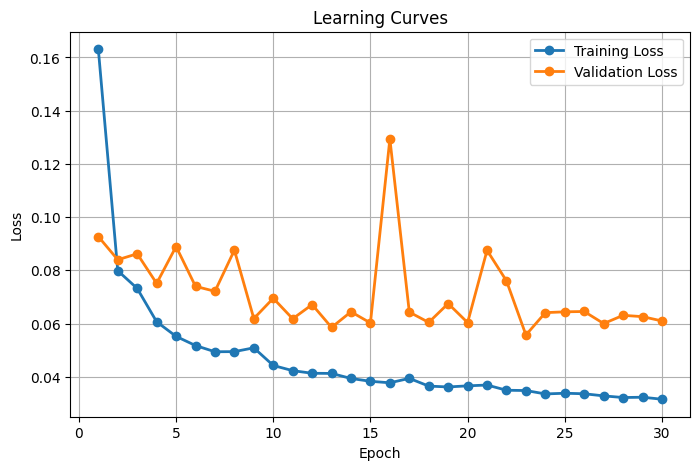

In [62]:
# ==========================================
# Plot Learning Curves
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o",
    linewidth=2,
    label="Training Loss",
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation Loss",
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Learning Curves")

plt.grid(True)

plt.legend()

plt.show()

In [64]:
# ==========================================
# Load Best Saved Model
# ==========================================

model = ML2Model().to(device)

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

model.eval()

print("Best ML2 Model Loaded Successfully!")

Best ML2 Model Loaded Successfully!


In [65]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Fixed random seed for reproducibility
# ---------------------------------------
random.seed(42)

# Number of validation windows to inspect
NUM_SAMPLES = 20

indices = random.sample(range(len(val_dataset)), NUM_SAMPLES)

print(indices)

[3648, 819, 9012, 8024, 7314, 4572, 3358, 17870, 2848, 13825, 1041, 976, 3070, 7164, 7623, 16559, 869, 18390, 6515, 17856]


In [66]:
for i, idx in enumerate(indices):
    ecg, gt = val_dataset[idx]

    ecg_input = ecg.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(ecg_input)
        pred = torch.argmax(pred, dim=2).squeeze().cpu().numpy()

    ecg = ecg.squeeze().numpy()
    gt = gt.numpy()

    x = np.arange(len(ecg))

    plt.figure(figsize=(18, 7))

    # ECG
    plt.subplot(3, 1, 1)
    plt.plot(x, ecg, color="black")
    plt.title(f"Validation Window {idx}")

    # Ground Truth
    plt.subplot(3, 1, 2)
    plt.plot(x, gt, linewidth=2)
    plt.yticks([0, 1, 2, 3])
    plt.title("Ground Truth")

    # Prediction
    plt.subplot(3, 1, 3)
    plt.plot(x, pred, linewidth=2)
    plt.yticks([0, 1, 2, 3])
    plt.title("Prediction")

    plt.tight_layout()
    plt.show()

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

In [67]:
import os

print(os.getcwd())
print(os.listdir())

/Users/vishwam/VSCode/PQRST_mapping
['mlModel1.ipynb', 'pipeline', 'aiRecommendation.txt', '.DS_Store', 'TODO.txt', '.pytest_cache', 'LEDSCHEMATIC.md', 'ML2_Baseline_TESTS (4).ipynb', 'Universal_Artifacts_ML1.ipynb', 'tests', 'best_ml2_model.pth', 'best_ml2_normalization.npz', 'README.md', '.gitignore', 'pqrst_landmarks_sel100.csv', 'ecg.csv', 'ML-ARCHITECTURE.md', 'esp32_code.cpp', 'physionet.org', '.git', 'ecg_gateway_synch.py', 'best_ml2_rpeak_guided.pth', 'ecgTriggersOnUno.cpp', 'experimentalModel2.ipynb', 'src']


In [68]:
# ==========================================
# Generate Predictions on One Validation Batch
# ==========================================

# Get one validation batch
batch_ecg, batch_labels = next(iter(val_loader))

# Move to device
batch_ecg = batch_ecg.to(device)
batch_labels = batch_labels.to(device)

# Disable gradient computation
with torch.no_grad():
    outputs = model(batch_ecg)

# Convert logits to predicted labels
predictions = torch.argmax(outputs, dim=2)

print("ECG Batch Shape      :", batch_ecg.shape)
print("Ground Truth Shape   :", batch_labels.shape)
print("Prediction Shape     :", predictions.shape)

print()

print("Unique Ground Truth Labels:")
print(torch.unique(batch_labels))

print()

print("Unique Predicted Labels:")
print(torch.unique(predictions))

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [64, 1, 1, 512]

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# Evaluate Entire Validation Dataset
# ==========================================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        batch_ecg = batch_ecg.to(device)

        outputs = model(batch_ecg)

        predictions = torch.argmax(outputs, dim=2)

        all_predictions.extend(predictions.cpu().numpy().flatten())

        all_labels.extend(batch_labels.numpy().flatten())

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels, all_predictions, average="weighted", zero_division=0
)

recall = recall_score(all_labels, all_predictions, average="weighted", zero_division=0)

f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)

print("\n===== Validation Metrics =====\n")

print(f"Accuracy :  {accuracy:.4f}")

print(f"Precision:  {precision:.4f}")

print(f"Recall   :  {recall:.4f}")

print(f"F1 Score :  {f1:.4f}")

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [64, 1, 1, 512]

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Visualize One Validation Window
# ==========================================

# Take first validation sample
ecg = batch_ecg[0].cpu().squeeze().numpy()

ground_truth = batch_labels[0].cpu().numpy()

prediction = predictions[0].cpu().numpy()

x = np.arange(len(ecg))

plt.figure(figsize=(18, 8))

# -----------------------------------
# ECG
# -----------------------------------

plt.subplot(3, 1, 1)

plt.plot(x, ecg, color="black")

plt.title("ECG Signal")

plt.grid(True)

# -----------------------------------
# Ground Truth
# -----------------------------------

plt.subplot(3, 1, 2)

plt.plot(x, ground_truth, linewidth=2)

plt.yticks([0, 1, 2, 3])

plt.title("Ground Truth Labels")

plt.grid(True)

# -----------------------------------
# Prediction
# -----------------------------------

plt.subplot(3, 1, 3)

plt.plot(x, prediction, linewidth=2)

plt.yticks([0, 1, 2, 3])

plt.title("Predicted Labels")

plt.grid(True)

plt.tight_layout()

plt.show()

NameError: name 'predictions' is not defined

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Publication Quality Visualization
# ==========================================

ecg = batch_ecg[0].cpu().squeeze().numpy()

ground_truth = batch_labels[0].cpu().numpy()

prediction = predictions[0].cpu().numpy()

x = np.arange(len(ecg))

plt.figure(figsize=(18, 8))

# ===================================================
# Ground Truth
# ===================================================

plt.subplot(2, 1, 1)

plt.plot(x, ecg, color="black", linewidth=1.5, label="ECG")

# P Wave
mask = ground_truth == 1

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="P Wave")

# QRS
mask = ground_truth == 2

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="QRS")

# T Wave
mask = ground_truth == 3

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="T Wave")

plt.title("Ground Truth Segmentation")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.legend()

# ===================================================
# Prediction
# ===================================================

plt.subplot(2, 1, 2)

plt.plot(x, ecg, color="black", linewidth=1.5, label="ECG")

# P Wave
mask = prediction == 1

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="P Wave")

# QRS
mask = prediction == 2

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="QRS")

# T Wave
mask = prediction == 3

plt.fill_between(x, ecg, where=mask, alpha=0.35, label="T Wave")

plt.title("ML2 Predicted Segmentation")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

NameError: name 'predictions' is not defined

In [72]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Choose fixed validation windows
# ----------------------------------------

random.seed(42)

NUM_WINDOWS = 10

indices = random.sample(range(len(val_dataset)), NUM_WINDOWS)

print("Validation Windows:", indices)

# ----------------------------------------
# Visualize
# ----------------------------------------

model.eval()

for idx in indices:
    ecg_tensor, gt_tensor = val_dataset[idx]

    ecg_input = ecg_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(ecg_input)
        pred = torch.argmax(output, dim=2).squeeze().cpu().numpy()

    ecg = ecg_tensor.squeeze().numpy()
    gt = gt_tensor.numpy()

    x = np.arange(len(ecg))

    plt.figure(figsize=(18, 8))

    # ==========================================
    # Ground Truth
    # ==========================================

    plt.subplot(2, 1, 1)

    plt.plot(x, ecg, color="black", linewidth=1.5, label="ECG")

    for label, name in zip([1, 2, 3], ["P Wave", "QRS", "T Wave"]):
        mask = gt == label

        plt.fill_between(x, ecg, where=mask, alpha=0.35, label=name)

    plt.title(f"Ground Truth - Validation Window {idx}")

    plt.grid(True)

    plt.legend()

    # ==========================================
    # Prediction
    # ==========================================

    plt.subplot(2, 1, 2)

    plt.plot(x, ecg, color="black", linewidth=1.5, label="ECG")

    for label, name in zip([1, 2, 3], ["P Wave", "QRS", "T Wave"]):
        mask = pred == label

        plt.fill_between(x, ecg, where=mask, alpha=0.35, label=name)

    plt.title(f"Prediction - Validation Window {idx}")

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

Validation Windows: [3648, 819, 9012, 8024, 7314, 4572, 3358, 17870, 2848, 13825]


RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

In [73]:
from sklearn.metrics import classification_report

# ==========================================
# Per-Class Evaluation
# ==========================================

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Background", "P Wave", "QRS", "T Wave"],
        digits=4,
        zero_division=0,
    )
)

ValueError: Number of classes, 0, does not match size of target_names, 4. Try specifying the labels parameter

/Users/vishwam/VSCode/.venv/lib/python3.12/site-packages/sklearn/metrics/_plot/confusion_matrix.py:155: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.im_ = ax.imshow(cm, **im_kw)
/Users/vishwam/VSCode/.venv/lib/python3.12/site-packages/sklearn/metrics/_plot/confusion_matrix.py:155: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.im_ = ax.imshow(cm, **im_kw)


ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 800x800 with 0 Axes>

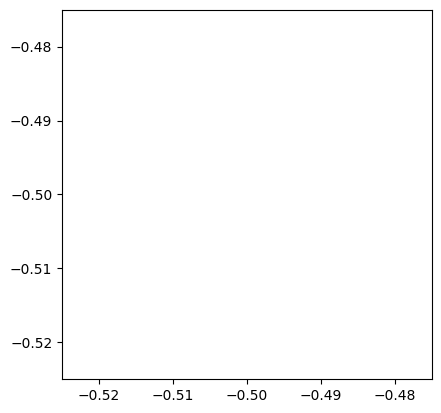

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Background", "P Wave", "QRS", "T Wave"]
)

plt.figure(figsize=(8, 8))

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - ML2 Baseline")

plt.grid(False)

plt.show()

/Users/vishwam/VSCode/.venv/lib/python3.12/site-packages/sklearn/metrics/_plot/confusion_matrix.py:155: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.im_ = ax.imshow(cm, **im_kw)
/Users/vishwam/VSCode/.venv/lib/python3.12/site-packages/sklearn/metrics/_plot/confusion_matrix.py:155: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.im_ = ax.imshow(cm, **im_kw)


ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 800x800 with 0 Axes>

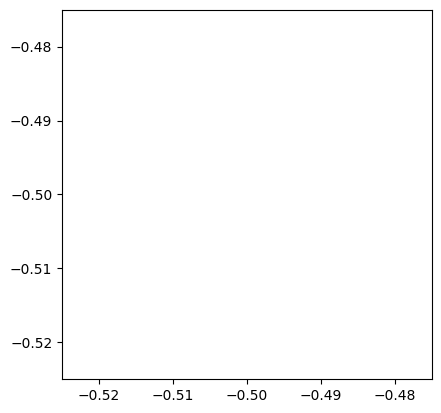

In [75]:
# ==========================================
# Normalized Confusion Matrix
# ==========================================

cm_normalized = confusion_matrix(all_labels, all_predictions, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=["Background", "P Wave", "QRS", "T Wave"],
)

plt.figure(figsize=(8, 8))

disp.plot(cmap="Blues", values_format=".2f")

plt.title("Normalized Confusion Matrix - ML2 Baseline")

plt.grid(False)

plt.show()

In [76]:
print("MODEL EVALUATION TESTS PHASE 3")

MODEL EVALUATION TESTS PHASE 3


In [77]:
from sklearn.metrics import f1_score
import pandas as pd

# ==========================================
# Compute Per-Window F1 Scores
# ==========================================

model.eval()

window_results = []

with torch.no_grad():
    for idx in range(len(val_dataset)):
        ecg, gt = val_dataset[idx]

        ecg_input = ecg.unsqueeze(0).to(device)

        output = model(ecg_input)

        pred = torch.argmax(output, dim=2).squeeze().cpu().numpy()

        gt = gt.numpy()

        f1 = f1_score(gt, pred, average="weighted", zero_division=0)

        window_results.append({"Window": idx, "F1": f1})

window_df = pd.DataFrame(window_results)

print("Done!")
print(window_df.head())

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

In [78]:
# ==========================================
# Sort Windows by F1
# ==========================================

worst_windows = window_df.sort_values(by="F1")

print(worst_windows.head(20))

NameError: name 'window_df' is not defined

In [79]:
# ==========================================
# Worst Windows with Record Names
# ==========================================

worst_windows = worst_windows.copy()

worst_windows["Record"] = record_ids[val_mask][worst_windows["Window"].values]

print(worst_windows.head(20))

NameError: name 'worst_windows' is not defined

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ==========================================
# Record-wise Performance Analysis
# ==========================================

model.eval()

record_results = []

# Validation record names
val_record_ids = record_ids[val_mask]

for record in np.unique(val_record_ids):
    indices = np.where(val_record_ids == record)[0]

    gt_all = []
    pred_all = []

    with torch.no_grad():
        for idx in indices:
            ecg, gt = val_dataset[idx]

            ecg_input = ecg.unsqueeze(0).to(device)

            output = model(ecg_input)

            pred = torch.argmax(output, dim=2).squeeze().cpu().numpy()

            gt_all.extend(gt.numpy())
            pred_all.extend(pred)

    accuracy = accuracy_score(gt_all, pred_all)

    precision = precision_score(gt_all, pred_all, average="weighted", zero_division=0)

    recall = recall_score(gt_all, pred_all, average="weighted", zero_division=0)

    f1 = f1_score(gt_all, pred_all, average="weighted", zero_division=0)

    record_results.append(
        {
            "Record": record,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
        }
    )

record_df = pd.DataFrame(record_results)

print(record_df.head())

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

In [81]:
record_df = record_df.sort_values(by="F1")

record_df

NameError: name 'record_df' is not defined

In [82]:
from sklearn.metrics import classification_report
import pandas as pd

# ==========================================
# Analyze Difficult Records
# ==========================================

DIFFICULT_RECORDS = ["sel41", "sel114", "sel14172"]

val_record_ids = record_ids[val_mask]

model.eval()

for record in DIFFICULT_RECORDS:
    print("\n" + "=" * 60)
    print(f"Record : {record}")
    print("=" * 60)

    indices = np.where(val_record_ids == record)[0]

    gt_all = []
    pred_all = []

    with torch.no_grad():
        for idx in indices:
            ecg, gt = val_dataset[idx]

            ecg_input = ecg.unsqueeze(0).to(device)

            output = model(ecg_input)

            pred = torch.argmax(output, dim=2).squeeze().cpu().numpy()

            gt_all.extend(gt.numpy())
            pred_all.extend(pred)

    print(
        classification_report(
            gt_all,
            pred_all,
            target_names=["Background", "P Wave", "QRS", "T Wave"],
            digits=4,
            zero_division=0,
        )
    )


Record : sel41


RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

In [83]:
# ==========================================
# Validation Windows for Difficult Records
# ==========================================

DIFFICULT_RECORDS = ["sel41", "sel14172"]

val_record_ids = record_ids[val_mask]

for record in DIFFICULT_RECORDS:
    indices = np.where(val_record_ids == record)[0]

    print(f"\n{record}")
    print(f"Total Windows : {len(indices)}")

    print("First 10 Window Indices:")

    print(indices[:10])


sel41
Total Windows : 877
First 10 Window Indices:
[8770 8771 8772 8773 8774 8775 8776 8777 8778 8779]

sel14172
Total Windows : 877
First 10 Window Indices:
[1754 1755 1756 1757 1758 1759 1760 1761 1762 1763]


In [84]:
# ==========================================
# Overlay Visualization for Difficult Records
# ==========================================

WINDOWS_TO_SHOW = [
    # sel41
    8770,
    8890,
    9010,
    9130,
    9250,
    # sel14172
    1754,
    1874,
    1994,
    2114,
    2234,
]

model.eval()

for idx in WINDOWS_TO_SHOW:
    ecg_tensor, gt_tensor = val_dataset[idx]

    ecg_input = ecg_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(ecg_input)

        pred = torch.argmax(output, dim=2).squeeze().cpu().numpy()

    ecg = ecg_tensor.squeeze().numpy()
    gt = gt_tensor.numpy()

    x = np.arange(len(ecg))

    plt.figure(figsize=(18, 8))

    # --------------------------------------
    # Ground Truth
    # --------------------------------------

    plt.subplot(2, 1, 1)

    plt.plot(x, ecg, color="black", linewidth=1.5)

    for label, name in zip([1, 2, 3], ["P Wave", "QRS", "T Wave"]):
        mask = gt == label

        plt.fill_between(x, ecg, where=mask, alpha=0.35, label=name)

    plt.title(f"Ground Truth - Window {idx}")

    plt.grid(True)

    plt.legend()

    # --------------------------------------
    # Prediction
    # --------------------------------------

    plt.subplot(2, 1, 2)

    plt.plot(x, ecg, color="black", linewidth=1.5)

    for label, name in zip([1, 2, 3], ["P Wave", "QRS", "T Wave"]):
        mask = pred == label

        plt.fill_between(x, ecg, where=mask, alpha=0.35, label=name)

    plt.title(f"Prediction - Window {idx}")

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1, 1, 1, 512]

## LUDB external validation

LUDB is hold-out data. This test does not train or fine-tune. LUDB is 500 Hz, so signal and doctor labels go to 250 Hz before test. Lead II is used.


In [48]:
# LUDB external test. Run this only after the notebook train/data cells.
# LUDB is never used for training. It is a hold-out test.
from pathlib import Path
from scipy.signal import resample_poly

LUDB_DIR = Path('physionet.org/files/ludb/1.0.1/data')
assert LUDB_DIR.exists(), f'Missing LUDB folder: {LUDB_DIR}'
assert 'train_mean' in globals() and 'train_std' in globals(), 'Run the QTDB training/data cells first.'

def ludb_labels_at_250(annotation, original_length):
    """LUDB annotation -> 0 Background, 1 P, 2 QRS, 3 T, at 250 Hz."""
    labels = np.zeros(round(original_length / 2), dtype=np.int64)
    start, kind = None, None
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == '(':
            start, kind = sample, None
        elif symbol == 'p':
            kind = 1
        elif symbol == 'N':
            kind = 2
        elif symbol == 't':
            kind = 3
        elif symbol == ')' and start is not None and kind is not None:
            left, right = round(start / 2), round(sample / 2)
            labels[left:right + 1] = kind
            start, kind = None, None
    return labels

def wave_intervals(labels, wave_class):
    mask = labels == wave_class
    edges = np.diff(np.r_[False, mask, False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))

def boundary_errors_ms(y_true, y_pred, class_map, fs=250):
    errors = {f'{name} onset': [] for name in class_map.values()}
    errors.update({f'{name} offset': [] for name in class_map.values()})
    missed = {name: 0 for name in class_map.values()}
    for truth, pred in zip(y_true, y_pred):
        for wave_class, name in class_map.items():
            predicted = wave_intervals(pred, wave_class)
            for start, end in wave_intervals(truth, wave_class):
                overlaps = [max(0, min(end, p_end) - max(start, p_start) + 1)
                            for p_start, p_end in predicted]
                if not overlaps or max(overlaps) == 0:
                    missed[name] += 1
                    continue
                p_start, p_end = predicted[int(np.argmax(overlaps))]
                errors[f'{name} onset'].append(abs(p_start - start) / fs * 1000)
                errors[f'{name} offset'].append(abs(p_end - end) / fs * 1000)
    return {key: np.mean(value) if value else np.nan for key, value in errors.items()}, missed

ludb_x, ludb_y, ludb_record_ids = [], [], []
for header in sorted(LUDB_DIR.glob('*.hea')):
    record_name = header.stem
    path = str(header.with_suffix(''))
    record = wfdb.rdrecord(path)
    lead = record.sig_name.index('ii')  # QTDB MLII matches LUDB lead II.
    signal = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
    annotation = wfdb.rdann(path, 'ii')
    labels = ludb_labels_at_250(annotation, len(record.p_signal))
    size = min(len(signal), len(labels))
    signal, labels = signal[:size], labels[:size]
    X, Y = create_windows(signal, labels, window_size=512, stride=256)
    ludb_x.append(X); ludb_y.append(Y); ludb_record_ids.extend([record_name] * len(X))

X_ludb = np.concatenate(ludb_x)
Y_ludb = np.concatenate(ludb_y)
ludb_record_ids = np.asarray(ludb_record_ids)
X_ludb = (X_ludb - train_mean) / train_std
print(f'LUDB external test: {len(np.unique(ludb_record_ids))} records, {len(X_ludb)} windows')



LUDB external test: 200 records, 1600 windows


In [85]:
# Score saved QTDB model on LUDB. No fitting here.
model = ML2Model().to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        ludb_predictions.append(model(batch).argmax(dim=2).cpu().numpy())
ludb_predictions = np.concatenate(ludb_predictions)

p_f1_ludb, t_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                                labels=[1, 3], average=None, zero_division=0)
macro_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                         labels=[0, 1, 2, 3], average='macro', zero_division=0)
errors_ludb, missed_ludb = boundary_errors_ms(Y_ludb, ludb_predictions, {1: 'P', 3: 'T'})
print(classification_report(Y_ludb.ravel(), ludb_predictions.ravel(),
                            labels=[0, 1, 2, 3],
                            target_names=['Background', 'P Wave', 'QRS', 'T Wave'],
                            digits=4, zero_division=0))
print(f'LUDB P F1: {p_f1_ludb:.4f} | T F1: {t_f1_ludb:.4f} | Macro F1: {macro_f1_ludb:.4f}')
display(pd.Series(errors_ludb, name='boundary MAE (ms)').to_frame())
print('Missed true waves:', missed_ludb)

record_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    record_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[3], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[0, 1, 2, 3], average='macro', zero_division=0)})
ludb_record_results = pd.DataFrame(record_rows).sort_values('macro F1')
display(ludb_record_results.head(10))



              precision    recall  f1-score   support

  Background     0.9272    0.7160    0.8080    509525
      P Wave     0.5987    0.9267    0.7275     76058
         QRS     0.7671    0.9255    0.8389     85944
      T Wave     0.6272    0.8678    0.7281    147673

    accuracy                         0.7849    819200
   macro avg     0.7301    0.8590    0.7756    819200
weighted avg     0.8258    0.7849    0.7894    819200

LUDB P F1: 0.7275 | T F1: 0.7281 | Macro F1: 0.7756


,boundary MAE (ms)
P onset,8.934391
T onset,27.134811
P offset,9.028118
T offset,37.242660


Missed true waves: {'P': 34, 'T': 104}


,record,P F1,T F1,macro F1
6,104,0.000000,0.613189,0.261399
11,109,0.000000,0.113115,0.376002
148,52,0.000000,0.582757,0.387797
195,95,0.000000,0.695013,0.420155
5,103,0.000000,0.593893,0.447826
3,101,0.000000,0.434706,0.454637
187,88,0.000000,0.582693,0.467840
31,127,0.143541,0.301370,0.477834
30,126,0.165584,0.188380,0.486282
129,35,0.000000,0.699543,0.503195
